Size of human dataset: 164
Size of AI dataset: 34727


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at microsoft/codebert-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
E:\python-projects\llm\cuda\Lib\site-packages\transformers\models\roberta\modeling_roberta.py:370: UserWarning: 1Torch was not compiled with flash attention. (Triggered internally at ..\aten\src\ATen\native\transformers\cuda\sdp_utils.cpp:455.)
  attn_output = torch.nn.functional.scaled_dot_product_attention(


Epoch [1/6], Batch [0], Loss: 0.6588
Epoch [1/6], Batch [10], Loss: 0.4349
Epoch [1/6], Batch [20], Loss: 0.3275
Epoch [1/6], Batch [30], Loss: 0.4878
Epoch [1/6], Batch [40], Loss: 0.0760
Epoch [1/6], Batch [50], Loss: 0.1342
Epoch 1/6, Loss: 0.2913, Accuracy: 0.8443
Validation Loss: 0.0275, Validation Accuracy: 0.9957
Epoch [2/6], Batch [0], Loss: 0.0130
Epoch [2/6], Batch [10], Loss: 0.0203
Epoch [2/6], Batch [20], Loss: 0.2160
Epoch [2/6], Batch [30], Loss: 0.1025
Epoch [2/6], Batch [40], Loss: 0.0568
Epoch [2/6], Batch [50], Loss: 0.0418
Epoch 2/6, Loss: 0.1243, Accuracy: 0.8861
Validation Loss: 0.0031, Validation Accuracy: 1.0000
Epoch [3/6], Batch [0], Loss: 0.0584
Epoch [3/6], Batch [10], Loss: 0.0416
Epoch [3/6], Batch [20], Loss: 0.1403
Epoch [3/6], Batch [30], Loss: 0.0275
Epoch [3/6], Batch [40], Loss: 0.0775
Epoch [3/6], Batch [50], Loss: 0.1891
Epoch 3/6, Loss: 0.1088, Accuracy: 0.8915
Validation Loss: 0.0030, Validation Accuracy: 1.0000
Epoch [4/6], Batch [0], Loss: 0.05

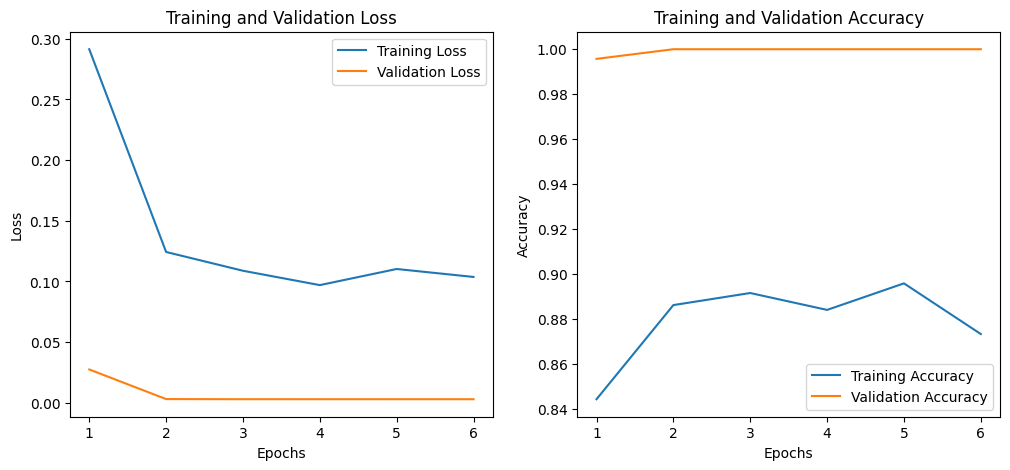

In [1]:
import torch
from torch import nn
from transformers import RobertaTokenizer, RobertaForSequenceClassification
from torch.optim import AdamW
from torch.optim.lr_scheduler import StepLR
from datasets import load_dataset
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from torch.cuda.amp import autocast, GradScaler


import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

# Step 1: Load the datasets
human_dataset = load_dataset("bigcode/humanevalpack", split="test")
ai_dataset = load_dataset("Rabinovich/Code-Generation-LLM-LoRA", split="train")
# Print dataset sizes
print(f"Size of human dataset: {len(human_dataset)}")
print(f"Size of AI dataset: {len(ai_dataset)}")

# Sample sizes
human_sample_size = min(164, len(human_dataset))
ai_sample_size = min(1000, len(ai_dataset))

# Select subsets
human_dataset = human_dataset.select(range(human_sample_size))
ai_dataset = ai_dataset.select(range(ai_sample_size))

# Step 2: Preprocess datasets
tokenizer = RobertaTokenizer.from_pretrained("microsoft/codebert-base")

def preprocess_dataset(dataset, label, column_name, bug_type_column=None):
    tokenized_samples = []
    labels = []
    attention_masks = []
    bug_types = []

    for idx, code_sample in enumerate(dataset[column_name]):
        tokenized_input = tokenizer(
            code_sample,
            padding='max_length',
            truncation=True,
            max_length=512,
            return_tensors='pt'
        )
        tokenized_samples.append(tokenized_input['input_ids'].squeeze(0))
        labels.append(label)
        attention_masks.append(tokenized_input['attention_mask'].squeeze(0))

        # If human-written code, add bug type if specified
        if bug_type_column and label == 0:
            bug_types.append(dataset[bug_type_column][idx])
        else:
            bug_types.append('ai_generated' if label == 1 else None)

    return tokenized_samples, labels, attention_masks, bug_types

# Preprocess human-written code dataset (using buggy_solution) and include bug_type
human_tokens, human_labels, human_attention_masks, human_bug_types = preprocess_dataset(
    human_dataset,
    0,
    'canonical_solution',
    bug_type_column='bug_type'
)

# Preprocess AI-generated code dataset (using content)
ai_tokens, ai_labels, ai_attention_masks, _ = preprocess_dataset(
    ai_dataset,
    1,
    'answer'
)

# Combine datasets
tokens = human_tokens + ai_tokens
labels = human_labels + ai_labels
attention_masks = human_attention_masks + ai_attention_masks

# Convert to PyTorch tensors
tokens = torch.stack(tokens)
labels = torch.tensor(labels)
attention_masks = torch.stack(attention_masks)

# Step 3: Define the CodeBERT model with Dropout
class CodeBERTClassifier(nn.Module):
    def __init__(self):
        super(CodeBERTClassifier, self).__init__()
        self.model = RobertaForSequenceClassification.from_pretrained("microsoft/codebert-base", num_labels=2)
        self.dropout = nn.Dropout(p=0.35)  # Add a dropout layer

    def forward(self, input_ids, attention_mask=None):
        outputs = self.model(input_ids, attention_mask=attention_mask)
        logits = self.dropout(outputs.logits)  # Apply dropout
        return logits

# Step 4: Split the data into training and validation sets
train_indices, val_indices = train_test_split(list(range(len(tokens))), test_size=0.2, random_state=42)

# Split the dataset
X_train, X_val = tokens[train_indices], tokens[val_indices]
y_train, y_val = labels[train_indices], labels[val_indices]
masks_train, masks_val = attention_masks[train_indices], attention_masks[val_indices]

# Create PyTorch Dataset and DataLoader
train_dataset = torch.utils.data.TensorDataset(X_train, y_train, masks_train)
val_dataset = torch.utils.data.TensorDataset(X_val, y_val, masks_val)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=16)
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=16, shuffle=False, num_workers=16)

# Step 5: Define training function with FP16
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = CodeBERTClassifier().to(device)
optimizer = AdamW(model.parameters(), lr=2.5e-5, weight_decay=1e-5)
scheduler = StepLR(optimizer, step_size=1, gamma=0.1)
scaler = GradScaler()

# Compute class weights to handle class imbalance
class_weights = torch.tensor([len(ai_labels) / len(human_labels), 1.0], device='cpu').to('cuda')  # Modify to your dataset
loss_fn = nn.CrossEntropyLoss(weight=class_weights)

def train_model(model, train_loader, val_loader, optimizer, scheduler, loss_fn, num_epochs=6, patience=2):
    torch.cuda.empty_cache()
    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []
    best_val_loss = float('inf')
    epochs_without_improvement = 0

    for epoch in range(num_epochs):
        model.train()
        total_loss = 0
        correct_predictions = 0
        total_predictions = 0

        for batch_idx, batch in enumerate(train_loader):
            input_ids, labels, attention_mask = batch[0].to(device), batch[1].to(device), batch[2].to(device)
            optimizer.zero_grad()

            with autocast():  # Mixed precision training
                outputs = model(input_ids, attention_mask=attention_mask)
                loss = loss_fn(outputs, labels)

            # Scale loss and perform backward pass
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            total_loss += loss.item()
            _, preds = torch.max(outputs, dim=1)
            correct_predictions += torch.sum(preds == labels).item()
            total_predictions += labels.size(0)

            if batch_idx % 10 == 0:  # Print every 10 batches
                print(f"Epoch [{epoch + 1}/{num_epochs}], Batch [{batch_idx}], Loss: {loss.item():.4f}")

        avg_loss = total_loss / len(train_loader)
        accuracy = correct_predictions / total_predictions
        print(f"Epoch {epoch + 1}/{num_epochs}, Loss: {avg_loss:.4f}, Accuracy: {accuracy:.4f}")

        # Validation loop
        model.eval()
        val_loss = 0
        val_correct = 0
        val_total = 0
        with torch.no_grad():
            for batch in val_loader:
                input_ids, labels, attention_mask = batch[0].to(device), batch[1].to(device), batch[2].to(device)

                with autocast():
                    outputs = model(input_ids, attention_mask=attention_mask)
                    loss = loss_fn(outputs, labels)

                val_loss += loss.item()
                _, preds = torch.max(outputs, dim=1)
                val_correct += torch.sum(preds == labels).item()
                val_total += labels.size(0)

        avg_val_loss = val_loss / len(val_loader)
        val_accuracy = val_correct / val_total
        print(f"Validation Loss: {avg_val_loss:.4f}, Validation Accuracy: {val_accuracy:.4f}")

        # Step the scheduler
        scheduler.step()

        # Early stopping logic
        train_losses.append(avg_loss)
        val_losses.append(avg_val_loss)
        train_accuracies.append(accuracy)
        val_accuracies.append(val_accuracy)

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= patience:
                print(f"Early stopping triggered after {epoch + 1} epochs.")
                break

    return train_losses, val_losses, train_accuracies, val_accuracies

# Train the model
train_losses, val_losses, train_accuracies, val_accuracies = train_model(
    model, train_loader, val_loader, optimizer, scheduler, loss_fn, num_epochs=6, patience=2
)

# Save the trained model
save_path = f"E:/python-projects/llm/Trained_models/codebert_classifier{max(train_accuracies)}.pth"
torch.save(model.state_dict(), save_path)
print(f"Model saved to {save_path}")

# Step 7: Plot training and validation loss/accuracy
epochs_range = range(1, len(train_losses) + 1)
plt.figure(figsize=(12, 5))

# Plotting Loss
plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_losses, label='Training Loss')
plt.plot(epochs_range, val_losses, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Plotting Accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs_range, train_accuracies, label='Training Accuracy')
plt.plot(epochs_range, val_accuracies, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()
